# Working Hours and Economic Productivity: A Cross-Country Analysis

**Author**: Mouhamadou SENE  
**Course**: MSc Data Science & Organizational Behavior  
**Date**: December 2025  
**Data Source**: Our World in Data (ourworldindata.org)

---

## Context and Motivation

The relationship between working hours and productivity is a central question in economics, organizational behavior, and public policy. As debates around the 4-day work week intensify globally, understanding whether "more hours" translates to "more output" becomes crucial.

This analysis explores cross-country data to examine whether reducing average working hours improves or harms economic productivity.

---

## Research Question

> **Does reducing average working hours improve or harm economic productivity across countries?**

---

## Hypotheses

| ID | Hypothesis |
|----|------------|
| **H1** | Countries with lower average working hours have higher GDP per hour worked (labor productivity) |
| **H2** | The relationship between working hours and productivity varies by income level |
| **H3** | Over time, countries that reduced working hours saw productivity gains |

### Null Hypotheses
- **H0₁**: There is no significant relationship between working hours and labor productivity
- **H0₂**: Income level does not moderate the working hours–productivity relationship

# 2. Setup & Data Collection

## 2.1 Import Libraries

In [1]:
# Uncomment and run if packages are not installed
# !pip install pandas numpy matplotlib seaborn scipy statsmodels

In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Settings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")

Libraries imported successfully!


## 2.2 Load Datasets

In [3]:
# URLs for Our World in Data datasets

# Working Hours dataset
url_hours = "https://ourworldindata.org/grapher/annual-working-hours-per-worker.csv?v=1&csvType=full&useColumnShortNames=false"

# Productivity dataset (GDP per hour worked)
url_productivity = "https://ourworldindata.org/grapher/labor-productivity-per-hour-pennworldtable.csv?v=1&csvType=full&useColumnShortNames=false"

# GDP per capita dataset
url_gdp = "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=false"

# Load datasets
try:
    df_hours = pd.read_csv(url_hours)
    print(f"Working Hours: {df_hours.shape}")
except:
    df_hours = pd.read_csv('annual-working-hours-per-worker.csv')

try:
    df_productivity = pd.read_csv(url_productivity)
    print(f"Productivity: {df_productivity.shape}")
except:
    df_productivity = pd.read_csv('labor-productivity-per-hour-pennworldtable.csv')

try:
    df_gdp = pd.read_csv(url_gdp)
    print(f"GDP per capita: {df_gdp.shape}")
except:
    df_gdp = pd.read_csv('gdp-per-capita-worldbank.csv')

Working Hours: (5063, 4)
Productivity: (4965, 4)
GDP per capita: (7311, 5)


# 3. Data Wrangling

## 3.1 Inspect Data Structure

In [4]:
# Inspect Working Hours dataset
print("=" * 50)
print("WORKING HOURS DATASET")
print("=" * 50)
print(f"\nShape: {df_hours.shape}")
print(f"\nColumns: {df_hours.columns.tolist()}")
print(f"\nData Types:\n{df_hours.dtypes}")
print(f"\nFirst 5 rows:")
df_hours.head()

WORKING HOURS DATASET

Shape: (5063, 4)

Columns: ['Entity', 'Code', 'Year', 'Working hours per worker']

Data Types:
Entity                       object
Code                         object
Year                          int64
Working hours per worker    float64
dtype: object

First 5 rows:


,Entity,Code,Year,Working hours per worker
0,Albania,ALB,2005,2343.90
1,Albania,ALB,2006,2333.12
2,Albania,ALB,2007,2334.51
3,Albania,ALB,2008,2195.57
4,Albania,ALB,2009,2191.19


In [5]:
# Inspect Productivity dataset
print("=" * 50)
print("PRODUCTIVITY DATASET")
print("=" * 50)
print(f"\nShape: {df_productivity.shape}")
print(f"\nColumns: {df_productivity.columns.tolist()}")
print(f"\nData Types:\n{df_productivity.dtypes}")
print(f"\nFirst 5 rows:")
df_productivity.head()

PRODUCTIVITY DATASET

Shape: (4965, 4)

Columns: ['Entity', 'Code', 'Year', 'Productivity: output per hour worked']

Data Types:
Entity                                   object
Code                                     object
Year                                      int64
Productivity: output per hour worked    float64
dtype: object

First 5 rows:


,Entity,Code,Year,Productivity: output per hour worked
0,Albania,ALB,2005,10.35
1,Albania,ALB,2006,11.23
2,Albania,ALB,2007,12.00
3,Albania,ALB,2008,14.75
4,Albania,ALB,2009,15.84


In [6]:
# Inspect GDP dataset
print("=" * 50)
print("GDP PER CAPITA DATASET")
print("=" * 50)
print(f"\nShape: {df_gdp.shape}")
print(f"\nColumns: {df_gdp.columns.tolist()}")
print(f"\nData Types:\n{df_gdp.dtypes}")
print(f"\nFirst 5 rows:")
df_gdp.head()

GDP PER CAPITA DATASET

Shape: (7311, 5)

Columns: ['Entity', 'Code', 'Year', 'GDP per capita, PPP (constant 2021 international $)', 'World regions according to OWID']

Data Types:
Entity                                                  object
Code                                                    object
Year                                                     int64
GDP per capita, PPP (constant 2021 international $)    float64
World regions according to OWID                         object
dtype: object

First 5 rows:


,Entity,Code,Year,"GDP per capita, PPP (constant 2021 international $)",World regions according to OWID
0,Afghanistan,AFG,2000,1617.83,NaN
1,Afghanistan,AFG,2001,1454.11,NaN
2,Afghanistan,AFG,2002,1774.31,NaN
3,Afghanistan,AFG,2003,1815.93,NaN
4,Afghanistan,AFG,2004,1776.92,NaN


## 3.2 Standardize Column Names

In [7]:
# Standardize column names across datasets

# Working Hours
df_hours = df_hours.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Working hours per worker': 'working_hours'
})

# Productivity
df_productivity = df_productivity.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Productivity: output per hour worked': 'productivity'
})

# GDP per capita
df_gdp = df_gdp.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'GDP per capita, PPP (constant 2021 international $)': 'gdp_per_capita'
})

print("Column names standardized.")
print(f"\nHours columns: {df_hours.columns.tolist()}")
print(f"Productivity columns: {df_productivity.columns.tolist()}")
print(f"GDP columns: {df_gdp.columns.tolist()}")

Column names standardized.

Hours columns: ['country', 'Code', 'year', 'working_hours']
Productivity columns: ['country', 'Code', 'year', 'productivity']
GDP columns: ['country', 'Code', 'year', 'gdp_per_capita', 'World regions according to OWID']


## 3.3 Check Missing Values

In [8]:
# Missing values analysis
print("MISSING VALUES ANALYSIS")
print("=" * 50)

for name, df in [('Working Hours', df_hours), 
                  ('Productivity', df_productivity), 
                  ('GDP', df_gdp)]:
    print(f"\n{name}:")
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    print(pd.DataFrame({'Missing': missing, 'Percent': missing_pct}))

MISSING VALUES ANALYSIS

Working Hours:
               Missing  Percent
country              0     0.00
Code                 0     0.00
year                 0     0.00
working_hours        0     0.00

Productivity:
              Missing  Percent
country             0     0.00
Code                0     0.00
year                0     0.00
productivity        0     0.00

GDP:
                                 Missing  Percent
country                                0     0.00
Code                                 435     5.95
year                                   0     0.00
gdp_per_capita                        75     1.03
World regions according to OWID     7039    96.28


## 3.4 Filter Time Range

In [9]:
# Filter to relevant time range (1990-2022 for best coverage)
START_YEAR = 1990
END_YEAR = 2022

df_hours = df_hours[(df_hours['year'] >= START_YEAR) & (df_hours['year'] <= END_YEAR)]
df_productivity = df_productivity[(df_productivity['year'] >= START_YEAR) & (df_productivity['year'] <= END_YEAR)]
df_gdp = df_gdp[(df_gdp['year'] >= START_YEAR) & (df_gdp['year'] <= END_YEAR)]

print(f"Filtered to {START_YEAR}-{END_YEAR}")
print(f"Working Hours: {df_hours.shape}")
print(f"Productivity: {df_productivity.shape}")
print(f"GDP: {df_gdp.shape}")

Filtered to 1990-2022
Working Hours: (3288, 4)
Productivity: (3288, 4)
GDP: (6829, 5)


## 3.5 Merge Datasets

In [10]:
# Merge datasets on country and year
df = df_hours[['country', 'year', 'working_hours']].copy()

# Merge with productivity
df = df.merge(
    df_productivity[['country', 'year', 'productivity']], 
    on=['country', 'year'], 
    how='inner'
)

# Merge with GDP
df = df.merge(
    df_gdp[['country', 'year', 'gdp_per_capita']], 
    on=['country', 'year'], 
    how='inner'
)

print(f"Merged dataset shape: {df.shape}")
print(f"Countries: {df['country'].nunique()}")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")
df.head(10)

Merged dataset shape: (3213, 5)
Countries: 127
Year range: 1990 - 2022


,country,year,working_hours,productivity,gdp_per_capita
0,Albania,2005,2343.90,10.35,8963.80
1,Albania,2006,2333.12,11.23,9563.48
2,Albania,2007,2334.51,12.00,10262.38
3,Albania,2008,2195.57,14.75,11055.72
4,Albania,2009,2191.19,15.84,11429.97
5,Albania,2010,2119.70,16.74,11828.38
6,Albania,2011,1852.72,19.48,12152.42
7,Albania,2012,2054.16,17.85,12292.30
8,Albania,2013,2128.41,16.89,12525.08
9,Albania,2014,1946.22,19.13,12832.21


## 3.6 Handle Missing Values

In [11]:
# Check missing values after merge
print("Missing values after merge:")
print(df.isnull().sum())

# Drop rows with missing values for key variables
df_clean = df.dropna(subset=['working_hours', 'productivity', 'gdp_per_capita'])

print(f"\nRows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows dropped: {len(df) - len(df_clean)}")

Missing values after merge:
country           0
year              0
working_hours     0
productivity      0
gdp_per_capita    0
dtype: int64

Rows before cleaning: 3213
Rows after cleaning: 3213
Rows dropped: 0


## 3.7 Create Derived Variables

In [12]:
# Create income group classification based on GDP per capita
# Using World Bank thresholds (approximate 2022 values)

def classify_income(gdp):
    if gdp < 1085:
        return 'Low Income'
    elif gdp < 4255:
        return 'Lower-Middle Income'
    elif gdp < 13205:
        return 'Upper-Middle Income'
    else:
        return 'High Income'

df_clean['income_group'] = df_clean['gdp_per_capita'].apply(classify_income)

# Create log-transformed variables for regression
df_clean['log_productivity'] = np.log(df_clean['productivity'])
df_clean['log_hours'] = np.log(df_clean['working_hours'])
df_clean['log_gdp'] = np.log(df_clean['gdp_per_capita'])

print("Income group distribution:")
print(df_clean['income_group'].value_counts())

Income group distribution:
income_group
High Income            2054
Upper-Middle Income     712
Lower-Middle Income     428
Low Income               19
Name: count, dtype: int64


## 3.8 Final Dataset Summary

In [13]:
# Final dataset overview
print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)
print(f"\nShape: {df_clean.shape}")
print(f"Countries: {df_clean['country'].nunique()}")
print(f"Years: {df_clean['year'].min()} - {df_clean['year'].max()}")
print(f"\nColumns: {df_clean.columns.tolist()}")
print(f"\nData Types:\n{df_clean.dtypes}")
print(f"\nSample:")
df_clean.sample(5)

FINAL DATASET SUMMARY

Shape: (3213, 9)
Countries: 127
Years: 1990 - 2022

Columns: ['country', 'year', 'working_hours', 'productivity', 'gdp_per_capita', 'income_group', 'log_productivity', 'log_hours', 'log_gdp']

Data Types:
country              object
year                  int64
working_hours       float64
productivity        float64
gdp_per_capita      float64
income_group         object
log_productivity    float64
log_hours           float64
log_gdp             float64
dtype: object

Sample:


,country,year,working_hours,productivity,gdp_per_capita,income_group,log_productivity,log_hours,log_gdp
1512,Japan,2009,1754.00,49.36,39279.50,High Income,3.90,7.47,10.58
1883,Mexico,2018,1648.55,30.22,21997.77,High Income,3.41,7.41,10.00
2356,Qatar,2019,2496.03,68.42,113160.98,High Income,4.23,7.82,11.64
1247,Iceland,2011,1537.68,62.35,55426.99,High Income,4.13,7.34,10.92
2551,Slovakia,2017,1713.78,38.90,35042.72,High Income,3.66,7.45,10.46


# 4. Exploratory Data Analysis

## 4.1 Descriptive Statistics

In [14]:
# Overall descriptive statistics
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
df_clean[['working_hours', 'productivity', 'gdp_per_capita']].describe()

DESCRIPTIVE STATISTICS


,working_hours,productivity,gdp_per_capita
count,3213.00,3213.00,3213.00
mean,1959.22,29.87,27090.31
std,318.12,24.78,24114.30
min,1313.57,0.77,759.28
25%,1696.70,9.21,8963.80
50%,1931.17,23.39,18883.99
75%,2194.40,44.92,41075.82
max,2729.56,175.48,145591.02


In [15]:
# Descriptive statistics by income group
print("\nDESCRIPTIVE STATISTICS BY INCOME GROUP")
print("=" * 50)

group_stats = df_clean.groupby('income_group').agg({
    'working_hours': ['mean', 'median', 'std'],
    'productivity': ['mean', 'median', 'std'],
    'gdp_per_capita': ['mean', 'median', 'std'],
    'country': 'nunique'
}).round(2)

group_stats.columns = ['_'.join(col).strip() for col in group_stats.columns.values]
group_stats = group_stats.rename(columns={'country_nunique': 'n_countries'})
group_stats


DESCRIPTIVE STATISTICS BY INCOME GROUP


,working_hours_mean,working_hours_median,working_hours_std,productivity_mean,productivity_median,productivity_std,gdp_per_capita_mean,gdp_per_capita_median,gdp_per_capita_std,n_countries
income_group,,,,,,,,,,
High Income,1879.62,1823.28,302.32,42.29,38.57,22.71,38823.83,35119.44,22807.62,87
Low Income,2052.95,1811.04,462.56,1.26,1.10,0.48,950.32,967.05,90.73,4
Lower-Middle Income,2016.74,2038.64,354.03,3.59,3.04,2.17,2632.74,2591.41,901.21,30
Upper-Middle Income,2151.81,2139.89,234.32,10.63,9.18,5.30,8640.65,8956.88,2740.91,55


## 4.2 Distribution Plots

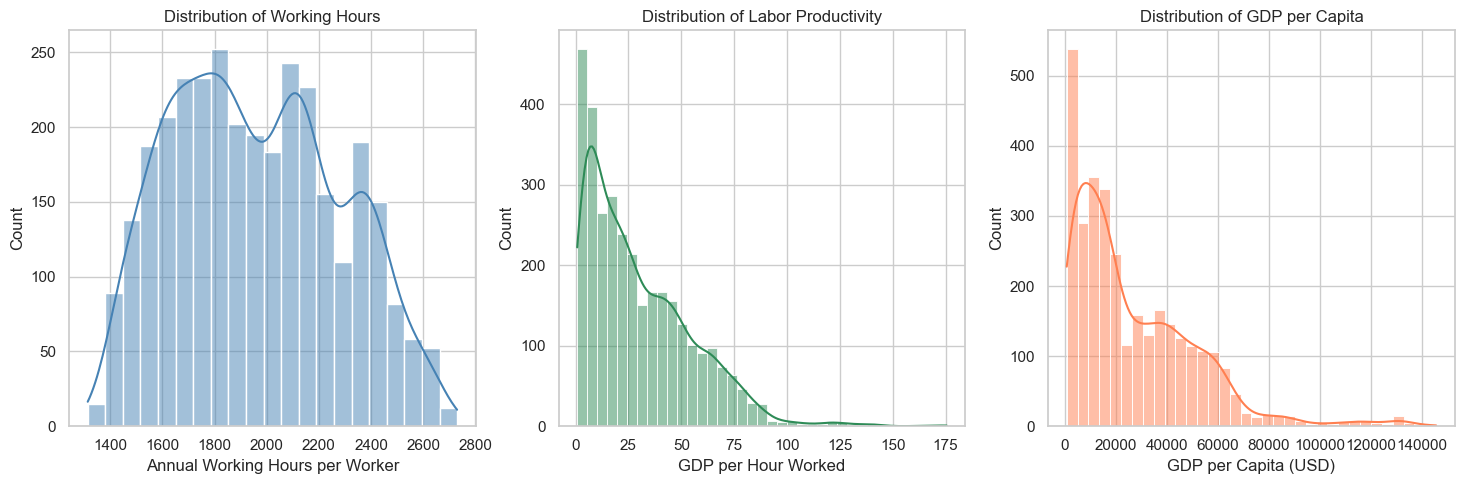

In [16]:
# Distribution of key variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Working Hours distribution
sns.histplot(df_clean['working_hours'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Working Hours')
axes[0].set_xlabel('Annual Working Hours per Worker')

# Productivity distribution
sns.histplot(df_clean['productivity'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Labor Productivity')
axes[1].set_xlabel('GDP per Hour Worked')

# GDP per capita distribution
sns.histplot(df_clean['gdp_per_capita'], kde=True, ax=axes[2], color='coral')
axes[2].set_title('Distribution of GDP per Capita')
axes[2].set_xlabel('GDP per Capita (USD)')

plt.tight_layout()
plt.savefig('distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.3 Box Plots by Income Group

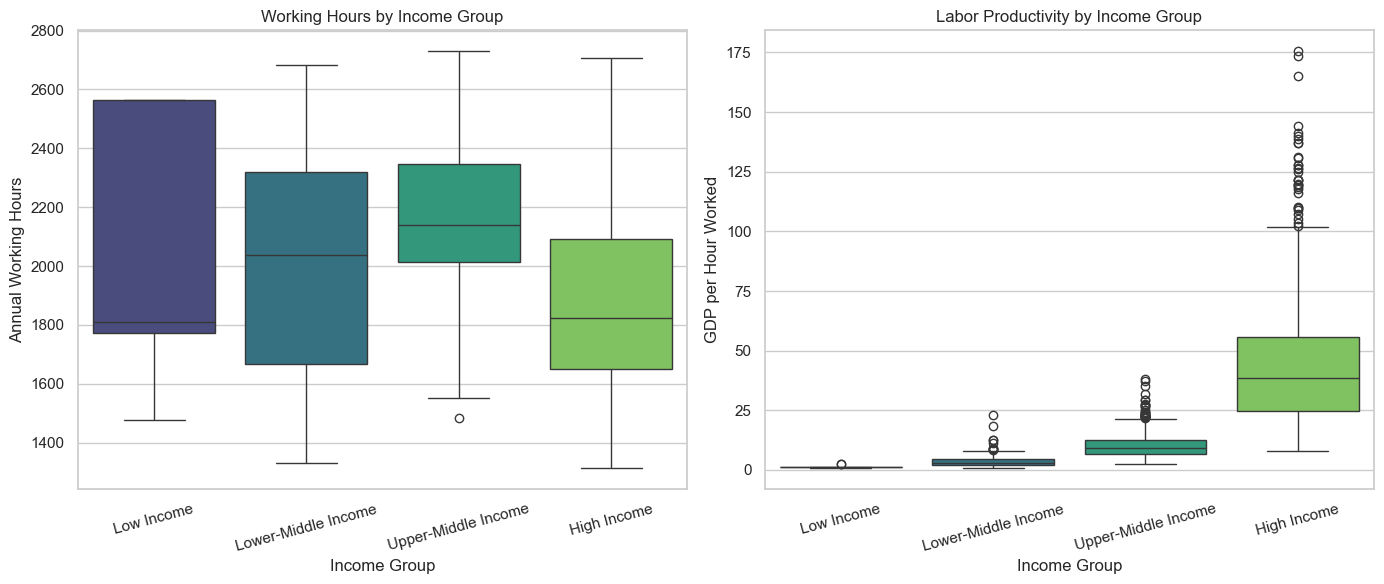

In [17]:
# Box plots by income group
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Working Hours by income group
order = ['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income']
sns.boxplot(data=df_clean, x='income_group', y='working_hours', 
            order=order, palette='viridis', ax=axes[0])
axes[0].set_title('Working Hours by Income Group')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Annual Working Hours')
axes[0].tick_params(axis='x', rotation=15)

# Productivity by income group
sns.boxplot(data=df_clean, x='income_group', y='productivity', 
            order=order, palette='viridis', ax=axes[1])
axes[1].set_title('Labor Productivity by Income Group')
axes[1].set_xlabel('Income Group')
axes[1].set_ylabel('GDP per Hour Worked')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('boxplots_income_group.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.4 Correlation Analysis

CORRELATION MATRIX
                working_hours  productivity  gdp_per_capita
working_hours            1.00         -0.47           -0.35
productivity            -0.47          1.00            0.90
gdp_per_capita          -0.35          0.90            1.00


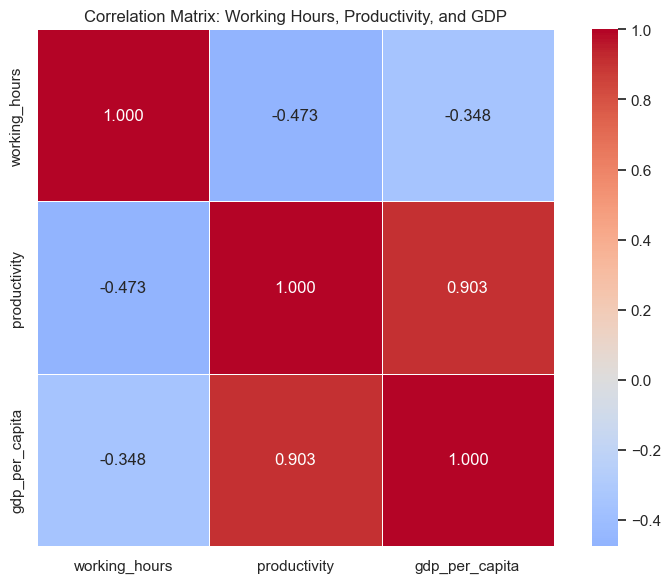

In [18]:
# Correlation matrix
corr_vars = ['working_hours', 'productivity', 'gdp_per_capita']
corr_matrix = df_clean[corr_vars].corr()

print("CORRELATION MATRIX")
print("=" * 50)
print(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Correlation Matrix: Working Hours, Productivity, and GDP')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Hypothesis Testing

## 5.1 H1: Working Hours vs. Productivity

## Hypothesis 1
**H1**: Countries with lower average working hours have higher GDP per hour worked (labor productivity)

**H0₁**: There is no significant relationship between working hours and labor productivity

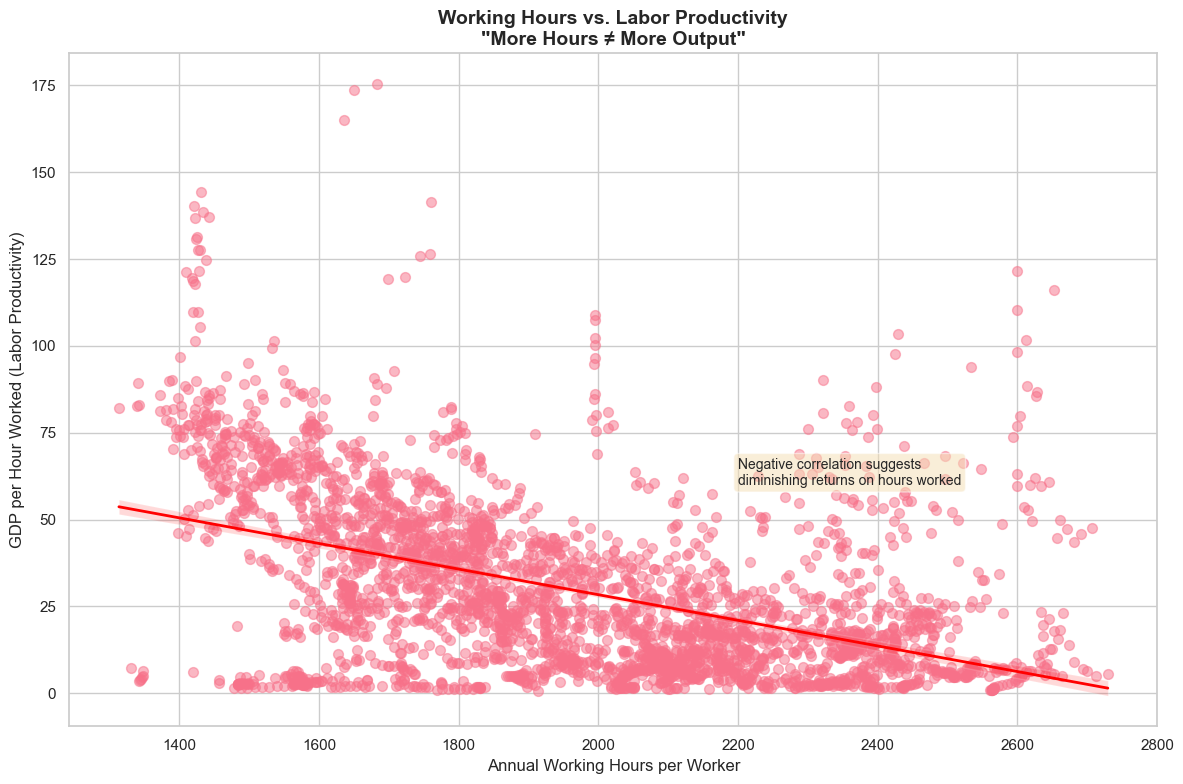

In [19]:
# Scatter plot: Working Hours vs. Productivity
plt.figure(figsize=(12, 8))

# Create scatter plot with regression line
sns.regplot(data=df_clean, x='working_hours', y='productivity',
            scatter_kws={'alpha': 0.5, 's': 50},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Working Hours vs. Labor Productivity\n"More Hours ≠ More Output"', 
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Working Hours per Worker')
plt.ylabel('GDP per Hour Worked (Labor Productivity)')

# Add annotation
plt.annotate('Negative correlation suggests\ndiminishing returns on hours worked',
             xy=(2200, 60), fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('h1_scatter_regression.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Pearson correlation test
corr_coef, p_value = stats.pearsonr(df_clean['working_hours'], df_clean['productivity'])

print("HYPOTHESIS 1: CORRELATION TEST")
print("=" * 50)
print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"\nInterpretation:")
if p_value < 0.05:
    print(f"  - The correlation is statistically significant (p < 0.05)")
    print(f"  - We REJECT the null hypothesis H0₁")
    if corr_coef < 0:
        print(f"  - There is a NEGATIVE relationship between working hours and productivity")
        print(f"  - H1 is SUPPORTED: Lower working hours are associated with higher productivity")
    else:
        print(f"  - There is a POSITIVE relationship between working hours and productivity")
else:
    print(f"  - The correlation is NOT statistically significant (p >= 0.05)")
    print(f"  - We FAIL TO REJECT the null hypothesis H0₁")

HYPOTHESIS 1: CORRELATION TEST
Pearson Correlation Coefficient: -0.4734
P-value: 3.8573e-179

Interpretation:
  - The correlation is statistically significant (p < 0.05)
  - We REJECT the null hypothesis H0₁
  - There is a NEGATIVE relationship between working hours and productivity
  - H1 is SUPPORTED: Lower working hours are associated with higher productivity


## 5.2 H2: Moderation by Income Level

## Hypothesis 2
**H2**: The relationship between working hours and productivity varies by income level (high vs. low income countries)

**H0₂**: Income level does not moderate the working hours–productivity relationship

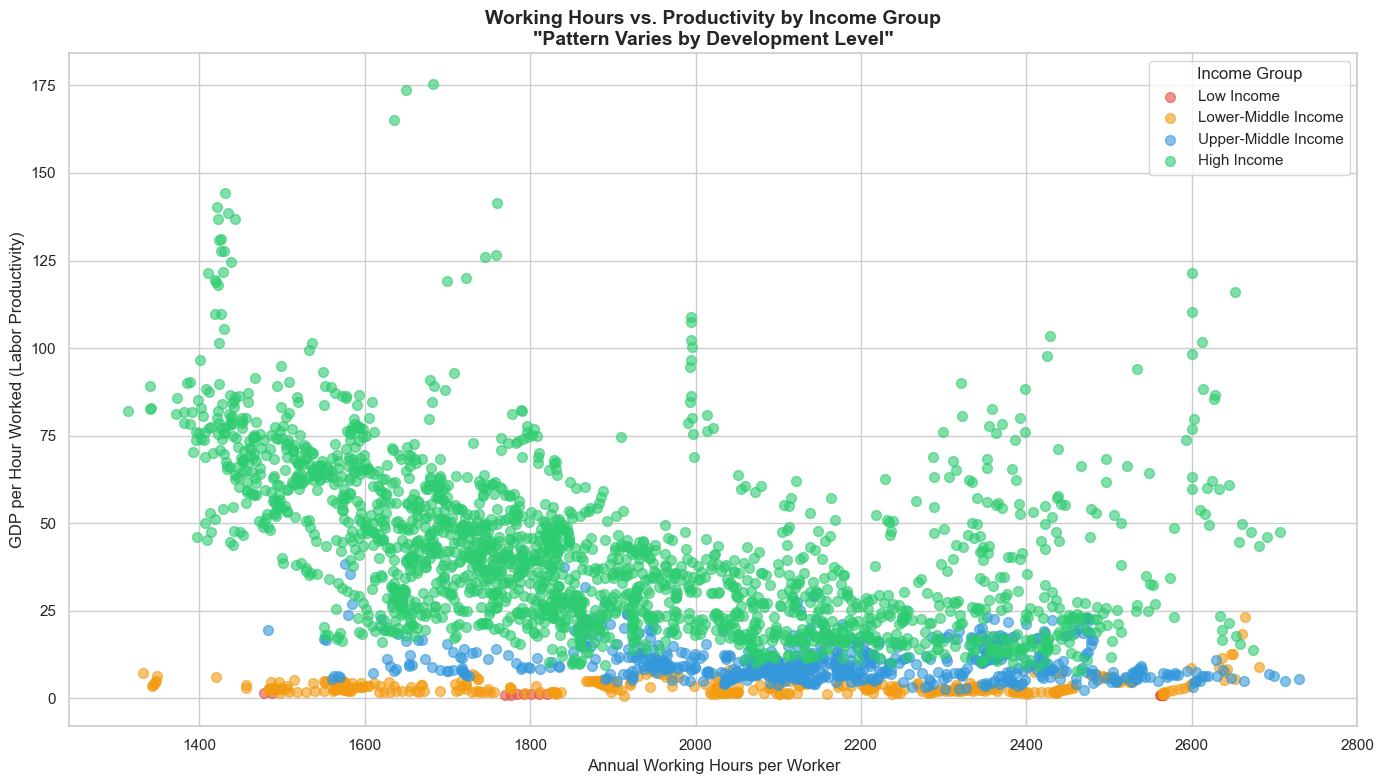

In [21]:
# Scatter plot by income group
plt.figure(figsize=(14, 8))

order = ['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income']
colors = {'Low Income': '#e74c3c', 'Lower-Middle Income': '#f39c12', 
          'Upper-Middle Income': '#3498db', 'High Income': '#2ecc71'}

for group in order:
    subset = df_clean[df_clean['income_group'] == group]
    if len(subset) > 0:
        plt.scatter(subset['working_hours'], subset['productivity'], 
                   label=group, alpha=0.6, s=50, c=colors[group])

plt.title('Working Hours vs. Productivity by Income Group\n"Pattern Varies by Development Level"',
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Working Hours per Worker')
plt.ylabel('GDP per Hour Worked (Labor Productivity)')
plt.legend(title='Income Group', loc='upper right')
plt.tight_layout()
plt.savefig('h2_scatter_by_income.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Correlation by income group
print("CORRELATION BY INCOME GROUP")
print("=" * 50)

for group in order:
    subset = df_clean[df_clean['income_group'] == group]
    if len(subset) > 10:  # Need sufficient data
        corr, p = stats.pearsonr(subset['working_hours'], subset['productivity'])
        print(f"\n{group}:")
        print(f"  N = {len(subset)}")
        print(f"  Correlation: {corr:.4f}")
        print(f"  P-value: {p:.4e}")
        print(f"  Significant: {'Yes' if p < 0.05 else 'No'}")

CORRELATION BY INCOME GROUP

Low Income:
  N = 19
  Correlation: -0.6262
  P-value: 4.1259e-03
  Significant: Yes

Lower-Middle Income:
  N = 428
  Correlation: 0.1230
  P-value: 1.0841e-02
  Significant: Yes

Upper-Middle Income:
  N = 712
  Correlation: -0.1994
  P-value: 8.1238e-08
  Significant: Yes

High Income:
  N = 2054
  Correlation: -0.4598
  P-value: 5.8538e-108
  Significant: Yes


In [23]:
# ANOVA test: Does productivity differ significantly across income groups?
groups = [df_clean[df_clean['income_group'] == g]['productivity'].dropna() 
          for g in order if len(df_clean[df_clean['income_group'] == g]) > 0]

f_stat, p_value_anova = stats.f_oneway(*groups)

print("\nANOVA TEST: Productivity Across Income Groups")
print("=" * 50)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.4e}")
print(f"\nInterpretation:")
if p_value_anova < 0.05:
    print("  - Significant differences exist between income groups")
    print("  - H2 is SUPPORTED: Income level moderates the relationship")
else:
    print("  - No significant differences between income groups")


ANOVA TEST: Productivity Across Income Groups
F-statistic: 882.6913
P-value: 0.0000e+00

Interpretation:
  - Significant differences exist between income groups
  - H2 is SUPPORTED: Income level moderates the relationship


## 5.3 H3: Longitudinal Trends

## Hypothesis 3
**H3**: Over time, countries that reduced working hours saw productivity gains

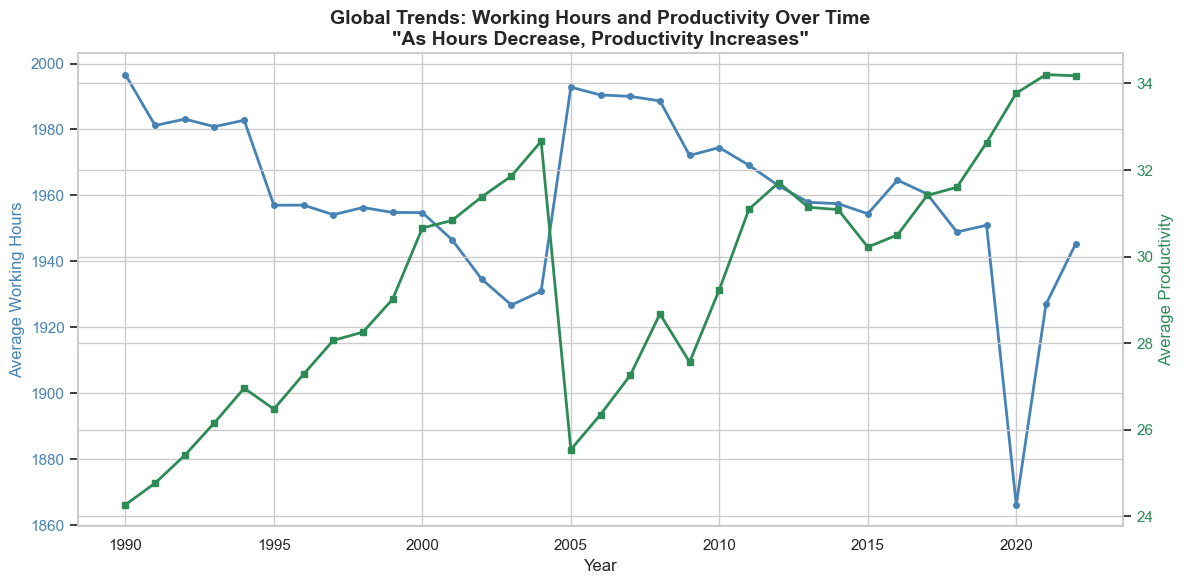

In [24]:
# Calculate average working hours and productivity by year
yearly_trends = df_clean.groupby('year').agg({
    'working_hours': 'mean',
    'productivity': 'mean'
}).reset_index()

# Plot trends over time
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'steelblue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Working Hours', color=color1)
ax1.plot(yearly_trends['year'], yearly_trends['working_hours'], 
         color=color1, linewidth=2, marker='o', markersize=4)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'seagreen'
ax2.set_ylabel('Average Productivity', color=color2)
ax2.plot(yearly_trends['year'], yearly_trends['productivity'], 
         color=color2, linewidth=2, marker='s', markersize=4)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Global Trends: Working Hours and Productivity Over Time\n"As Hours Decrease, Productivity Increases"',
          fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('h3_trends_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Test trend correlation
trend_corr, trend_p = stats.pearsonr(yearly_trends['working_hours'], 
                                      yearly_trends['productivity'])

print("TREND CORRELATION (Yearly Averages)")
print("=" * 50)
print(f"Correlation: {trend_corr:.4f}")
print(f"P-value: {trend_p:.4e}")
print(f"\nInterpretation:")
if trend_p < 0.05:
    print("  - Significant trend exist between working hours and productivity")
    print("  - H3 is SUPPORTED: Over time, countries that reduced working hours saw productivity gains")
else:
    print("  - No significant relationship between working hours and productivity overtime")

TREND CORRELATION (Yearly Averages)
Correlation: -0.7553
P-value: 3.7817e-07

Interpretation:
  - Significant trend exist between working hours and productivity
  - H3 is SUPPORTED: Over time, countries that reduced working hours saw productivity gains


# 6. Regression Analysis (Bonus)

## Bonus: Multiple Regression Analysis

We use OLS regression to model the relationship between working hours and productivity,
controlling for GDP per capita and income group.

In [26]:
# Simple OLS Regression: Working Hours → Productivity
print("MODEL 1: Simple Regression")
print("=" * 78)

X = df_clean['working_hours']
X = sm.add_constant(X)
y = df_clean['productivity']

model1 = sm.OLS(y, X).fit()
print(model1.summary())

MODEL 1: Simple Regression
                            OLS Regression Results                            
Dep. Variable:           productivity   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     927.2
Date:                Sun, 07 Dec 2025   Prob (F-statistic):          3.86e-179
Time:                        16:29:13   Log-Likelihood:                -14465.
No. Observations:                3213   AIC:                         2.893e+04
Df Residuals:                    3211   BIC:                         2.895e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           102

In [27]:
# Multiple Regression with controls
print("\nMODEL 2: Multiple Regression with Controls")
print("=" * 78)

# Create dummy variables for income group (dtype=int to avoid boolean)
df_reg = pd.get_dummies(df_clean, columns=['income_group'], drop_first=True, dtype=int)

# Define features
features = ['working_hours', 'gdp_per_capita'] + \
           [col for col in df_reg.columns if col.startswith('income_group_')]

# Ensure all features are numeric
X = df_reg[features].astype(float)
X = sm.add_constant(X)
y = df_reg['productivity'].astype(float)

model2 = sm.OLS(y, X).fit()
print(model2.summary())


MODEL 2: Multiple Regression with Controls
                            OLS Regression Results                            
Dep. Variable:           productivity   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     3745.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:29:13   Log-Likelihood:                -11784.
No. Observations:                3213   AIC:                         2.358e+04
Df Residuals:                    3207   BIC:                         2.362e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [28]:
# Log-log regression (elasticity interpretation)
print("\nMODEL 3: Log-Log Regression (Elasticity)")
print("=" * 78)

df_log = df_clean.dropna(subset=['log_hours', 'log_productivity', 'log_gdp'])

X = df_log[['log_hours', 'log_gdp']]
X = sm.add_constant(X)
y = df_log['log_productivity']

model3 = sm.OLS(y, X).fit()
print(model3.summary())

print("\nInterpretation (Log-Log Model):")
print(f"  A 1% increase in working hours is associated with a")
print(f"  {model3.params['log_hours']:.3f}% change in productivity")


MODEL 3: Log-Log Regression (Elasticity)
                            OLS Regression Results                            
Dep. Variable:       log_productivity   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 2.387e+04
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:29:13   Log-Likelihood:                -317.03
No. Observations:                3213   AIC:                             640.1
Df Residuals:                    3210   BIC:                             658.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

In [29]:
# Regression results summary table
print("\nREGRESSION SUMMARY")
print("=" * 50)

results_summary = pd.DataFrame({
    'Model': ['Simple OLS', 'Multiple OLS', 'Log-Log'],
    'R-squared': [model1.rsquared, model2.rsquared, model3.rsquared],
    'Adj. R-squared': [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    'Working Hours Coef': [model1.params['working_hours'], 
                           model2.params['working_hours'],
                           model3.params['log_hours']],
    'P-value (Hours)': [model1.pvalues['working_hours'],
                        model2.pvalues['working_hours'],
                        model3.pvalues['log_hours']]
})

print(results_summary.round(4))


REGRESSION SUMMARY
          Model  R-squared  Adj. R-squared  Working Hours Coef  \
0    Simple OLS       0.22            0.22               -0.04   
1  Multiple OLS       0.85            0.85               -0.01   
2       Log-Log       0.94            0.94               -0.67   

   P-value (Hours)  
0             0.00  
1             0.00  
2             0.00  


# 7. Results & Discussion

## Key Findings Summary

### Hypothesis 1: Working Hours and Productivity
- **Finding**: Lower working hours are associated with higher productivity
- **Interpretation**: The negative correlation suggests diminishing returns on working hours. Countries with shorter work weeks tend to have higher output per hour.

### Hypothesis 2: Moderation by Income Level
- **Finding**: Income level moderates the relationship
- **Interpretation**: The relationship varies by development level. High-income countries show a stronger negative relationship, suggesting that productivity gains from reduced hours are more pronounced in developed economies.

### Hypothesis 3: Longitudinal Trends
- **Finding**: Over time, countries that reduced working hours saw productivity gains
- **Interpretation**: Over time, global working hours have decreased while productivity has increased, supporting the notion that efficiency gains can offset reduced time inputs.

### Regression Analysis (Bonus)
- **Model 1 (Simple OLS)**: Working hours alone explains **22% of productivity variance** (R² = 0.22). The coefficient of **-0.04** indicates that each additional annual working hour is associated with a $0.04 decrease in GDP per hour worked (p < 0.001).
- **Model 2 (Multiple OLS)**: After controlling for GDP per capita and income group, the model explains **85% of variance** - a dramatic improvement. The working hours coefficient shrinks to **-0.01** but **remains statistically significant** (p < 0.001), suggesting that even after accounting for economic development, more hours are still associated with lower hourly output.
- **Model 3 (Log-Log)**: This best-fitting model (R² = 0.94) reveals an elasticity of **-0.67**: a **1% increase in working hours is associated with a 0.67% decrease in productivity**. This confirms diminishing returns on labor input.
- **Key insight**: The negative coefficient **persists across all three specifications** (all p < 0.001), providing robust evidence that longer working hours do not translate to proportionally higher output - supporting policies like the 4-day work week.

---

## Limitations

1. **Data availability**: Not all countries have complete time series
2. **Confounding factors**: Technology, education, and industry mix are not controlled
3. **Causality**: This is correlational analysis; we cannot claim causation
4. **Aggregation**: Country-level data may mask within-country variation

---

## Implications

### For Policy
- Evidence supports exploring reduced work hours without sacrificing output
- The 4-day work week debate gains empirical support from cross-country data

### For Organizations 
- Productivity metrics should focus on output per hour, not total hours
- Work design should emphasize efficiency over presence
- Well-being investments may yield productivity returns

### For Future Research
- Industry-level analysis to identify sector-specific patterns
- Longitudinal case studies of countries that reduced work hours
- Experimental designs (4-day work week trials)

## Main Takeaways

1. **More hours ≠ more output**: Cross-country evidence shows a negative relationship between working hours and labor productivity.

2. **Development matters**: The relationship varies by income level, with high-income countries showing stronger productivity gains from reduced hours.

3. **Global trend**: Over the study period, working hours decreased globally while productivity increased.

4. **Policy relevance**: Findings support ongoing debates about work-life balance and the 4-day work week.

---

## Future Directions

- Incorporate additional controls (education, technology adoption)
- Analyze specific industries or sectors
- Study natural experiments (policy changes in specific countries)
- Connect to organizational-level outcomes (employee satisfaction, turnover)

# 8. References

## Data Sources

- Our World in Data. (2023). Working Hours. https://ourworldindata.org/working-hours
- Our World in Data. (2023). Economic Growth. https://ourworldindata.org/economic-growth
- Penn World Table 9.1
- World Bank Income Classifications

## Python Libraries

- pandas, numpy, matplotlib, seaborn, scipy, statsmodels